# Zero-Order Hold: TOPS problems.

This tutorial shows how to solve benchmark problems from the TOPS database (Trajectory Optimisation Problems in Space) using pykep wrappers based on the Zero-Order Hold (ZOH) transcription described in {cite:p}`izzo2026zoh`.

We focus on four benchmark families exposed in the gym module:
- {class}`pykep.trajopt.gym.tops_twobody` (two-body, Cartesian state)
- {class}`pykep.trajopt.gym.tops_mee` (two-body, modified equinoctial elements)
- {class}`pykep.trajopt.gym.tops_cr3bp` (CR3BP)
- {class}`pykep.trajopt.gym.tops_ss` (solar sailing)

All of them are Non-Linear Programming Problems, in a UDP format compatible with pygmo {cite:p}`pagmo`,
and all follow the same workflow:
1. instantiate a TOPS benchmark wrapper,
2. build `pg.problem`,
3. verify analytical gradients against finite differences,
4. solve with IPOPT,
5. inspect the trajectory and controls.

For API details and background material, see:
- [Trajectory optimization API](../trajopt.rst)
- [TOPS benchmark overview](../gym.rst)
- [Zero-Order Hold leg tutorial](./leg_zoh.ipynb)

## Decision vectors and time encoding

The wrappers in this notebook are built on:
- {class}`pykep.trajopt.zoh_point2point` (low-thrust)
- {class}`pykep.trajopt.zoh_ss_point2point` (solar-sail)

For {class}`pykep.trajopt.zoh_point2point`, the decision vector is:

$$
\mathbf{x} = [m_f] + [T_0, i_{x0}, i_{y0}, i_{z0}] + \cdots + [T_{N-1}, i_{x,N-1}, i_{y,N-1}, i_{z,N-1}] + [tof] (+ [w_0,\ldots,w_{N-1}])
$$

where:
- $m_f$ is the final mass,
- $(T_k, i_{xk}, i_{yk}, i_{zk})$ is the segment thrust magnitude and direction,
- $tof$ is total time of flight,
- $w_k$ are optional softmax weights (only for `time_encoding="softmax"`).

For {class}`pykep.trajopt.zoh_ss_point2point`, the decision vector is:

$$
\mathbf{x} = [\alpha_0, \beta_0, \ldots, \alpha_{N-1}, \beta_{N-1}] + [tof] (+ [w_0,\ldots,w_{N-1}])
$$

where $(\alpha_k, \beta_k)$ are sail cone and clock angles (RTN frame) held constant on each segment.

### Uniform vs softmax time grids

With `time_encoding="uniform"`, segment durations are equal. With `time_encoding="softmax"`, durations are learned via weights and satisfy positivity and partition of unity:

$$
\Delta t_k = tof\,\mathrm{softmax}(\mathbf{w})_k, \qquad t_{k+1}=t_k+\Delta t_k.
$$

We start from a two-body Cartesian case and then repeat the same solver pipeline on MEE, CR3BP, and solar-sail dynamics.

This makes the notebook useful as both:
- a practical TOPS benchmark tutorial, and
- a template for your own ZOH-based optimization studies.

First, import the required packages.

In [1]:
# Core numerics, optimization, and plotting imports used throughout the tutorial
import pykep as pk 
import numpy as np
import pygmo as pg

from matplotlib import pyplot as plt

Configure the nonlinear optimizer.

We use IPOPT with strict tolerances so the gradient checks and feasibility status are meaningful when comparing benchmark instances.

In [2]:
# IPOPT reference setup used consistently across all TOPS sections
ipopt_integer_options = {
    "max_iter": 2000,
}
ipopt_numeric_options = {
    "tol": 1e-10,
}
ipopt_string_options = {
    "sb": "yes",
}

ipopt = pg.ipopt()
ipopt.set_integer_options(ipopt_integer_options)
ipopt.set_numeric_options(ipopt_numeric_options)
ipopt.set_string_options(ipopt_string_options)
algo = pg.algorithm(ipopt)

# Two-body dynamics (Cartesian)

This section uses a TOPS two-body benchmark wrapped by {class}`pykep.trajopt.gym.tops_twobody`.

Workflow:
1. load a named TOPS case (`P0`, `P1`, ...),
2. build the pygmo problem and set feasibility tolerance,
3. verify analytical gradients,
4. solve with IPOPT and inspect mass / time-of-flight / geometry.

In [3]:
# 1) Select a TOPS benchmark case and build the wrapped UDP
prob_name = "P0"
udp = pk.trajopt.gym.tops_twobody(prob_name, nseg=10, time_encoding="uniform")
print(udp.extra_info)

# 2) Wrap into a pygmo problem and set feasibility tolerance for reporting
prob = pg.problem(udp)
prob.c_tol = 1e-7 # This affects pagmo feasibility checks, not IPOPT's internal tol

Mildly-elliptic to mildly-elliptic transfer (e_s~0.201, e_f~0.210) in fixed tof -> T=0.22N, Isp=3000s


Check analytical gradients against finite differences before optimization.

For these direct methods, this is a key reliability step: if this check is poor, solver behavior and convergence claims are not trustworthy.

In [4]:
# Compare analytical and finite-difference gradients at a random initial point
pop = pg.population(prob, 1)
grad_err = pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8) - udp.gradient(pop.champion_x)
grad_err.max(), grad_err.min()

(1.3469916998703861e-07, -2.4193729492028027e-07)

In [5]:
# Solve and report a compact set of diagnostics
pop = algo.evolve(pop)
print(prob.feasibility_f(pop.champion_f))
print("Objective:", pop.champion_f[0])
print("Final mass:", pop.champion_x[0] * udp.MASS)
print("Final tof:", pop.champion_x[4*udp.nseg+1] * udp.TIME)

True
Objective: -0.919340661912
Final mass: 0.919340661912
Final tof: 11.0


Text(0.5, 0.92, 'yz - view')

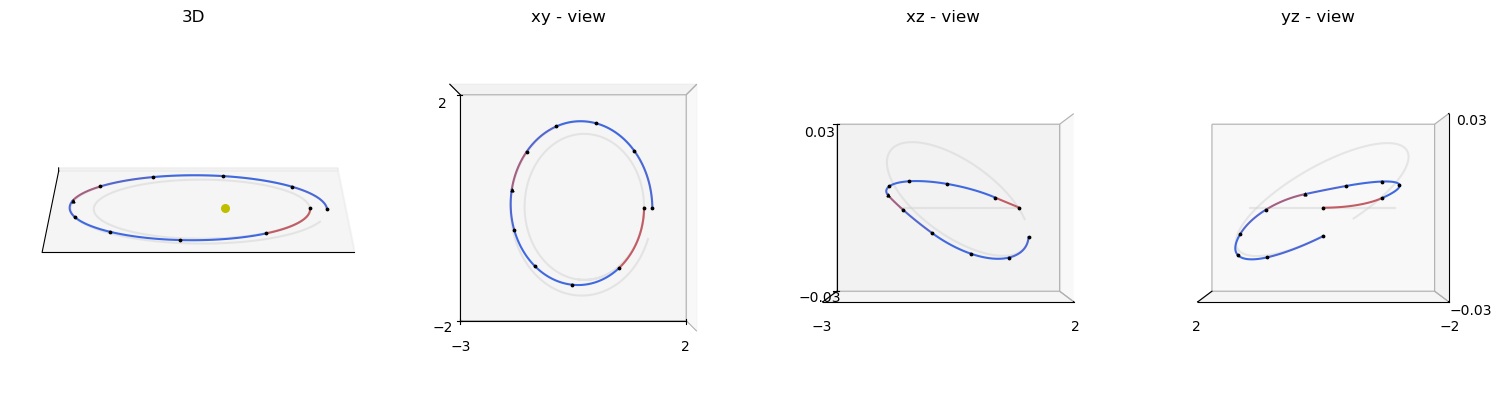

In [6]:
# Multi-view plotting helper for quick geometric inspection
fig = plt.figure(figsize=(15, 4), layout="constrained")

ax3d = fig.add_subplot(1, 4, 1, projection="3d")
ax_xy = fig.add_subplot(1, 4, 2, projection="3d")
ax_xz = fig.add_subplot(1, 4, 3, projection="3d")
ax_yz = fig.add_subplot(1, 4, 4, projection="3d")

axes = [ax3d, ax_xy, ax_xz, ax_yz]

for ax in axes:
    udp.plot(
        x=pop.champion_x,
        N=100,
        mark_segments=True,
        s=3,
        c="k",
        ax=ax,
        orbit_color="lightgray",
    )

# Keep only boundary ticks to emphasize shape over scale details
for ax in axes:
    ax.set_xticks([ax.get_xticks()[0], ax.get_xticks()[-1]])
    ax.set_yticks([ax.get_yticks()[0], ax.get_yticks()[-1]])
    ax.set_zticks([ax.get_zticks()[0], ax.get_zticks()[-1]])
ax_xy.set_zticks([])
ax_xz.set_yticks([])
ax_yz.set_xticks([])

ax3d.view_init(elev=20, azim=270)
ax3d.set_aspect("equal")
pk.plot.add_sun(ax3d)

ax_xy.view_init(elev=90, azim=-90)
ax_xz.view_init(elev=0, azim=-90)
ax_yz.view_init(elev=0, azim=180)

ax3d.set_title("3D")
ax_xy.set_title("xy - view")
ax_xz.set_title("xz - view")
ax_yz.set_title("yz - view")

In [ ]:
udp.plot_throttle(pop.champion_x)

# Two-body dynamics (Modified Equinoctial Elements)

We now solve the MEE variant through {class}`pykep.trajopt.gym.tops_mee`, reusing the exact same numerical pipeline.

Only the internal dynamics/state representation changes; the user-facing optimization workflow remains identical.

For element definitions and conversions, see [Elements and conversions](../elements.rst).

In [7]:
# 1) Load a TOPS MEE benchmark and inspect its metadata
prob_name = "P0"
udp = pk.trajopt.gym.tops_mee(prob_name, nseg=10, time_encoding="uniform")
print(udp.extra_info)

# 2) Create pygmo wrapper and harmonize feasibility tolerance across sections
prob = pg.problem(udp)
prob.c_tol = 1e-7 # This affects pagmo feasibility checks, not IPOPT's internal tol

Dionysus problem (doi: 10.2514/1.G000379) - Fixed time


In [8]:
# Gradient consistency check for the MEE benchmark
pop = pg.population(prob, 1)
grad_err = pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8) - udp.gradient(pop.champion_x)
grad_err.max(), grad_err.min()

(1.0853190796633605e-06, -1.97144447500186e-06)

In [9]:
# Solve and summarize
pop = algo.evolve(pop)
print(prob.feasibility_f(pop.champion_f))
print("Objective:", pop.champion_f[0])
print("Final mass:", pop.champion_x[0] * udp.MASS)
print("Final tof:", pop.champion_x[4*udp.nseg+1] * udp.TIME)

True
Objective: -0.593644774919
Final mass: 0.593644774919
Final tof: 60.7909197787


Text(0.5, 0.92, 'yz - view')

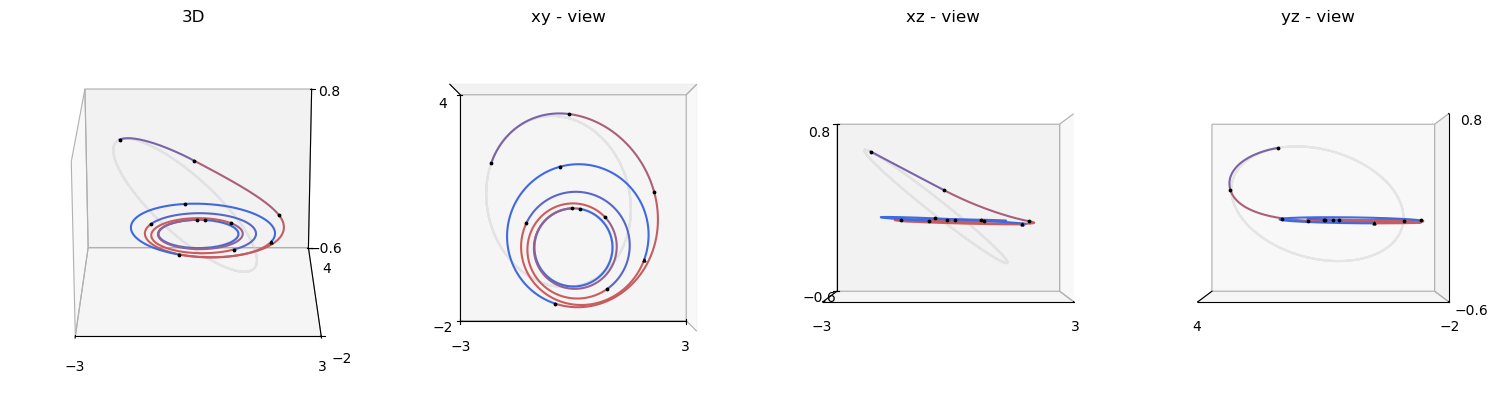

In [10]:
fig = plt.figure(figsize=(15, 4), layout="constrained")

ax3d = fig.add_subplot(1, 4, 1, projection="3d")  # 3D view
ax_xy = fig.add_subplot(1, 4, 2, projection="3d")  # look along +z (XY plane)
ax_xz = fig.add_subplot(1, 4, 3, projection="3d")  # look along +y (XZ plane)
ax_yz = fig.add_subplot(1, 4, 4, projection="3d")  # look along +x (YZ plane)

axes = [ax3d, ax_xy, ax_xz, ax_yz]

for ax in axes:
    udp.plot(
        x=pop.champion_x,
        N=300,
        mark_segments=True,
        s=3,
        c="k",
        ax=ax,
        orbit_color="lightgray",
    )

# We remove the ticks for clarity
for ax in axes:
    ax.set_xticks([ax.get_xticks()[0], ax.get_xticks()[-1]])
    ax.set_yticks([ax.get_yticks()[0], ax.get_yticks()[-1]])
    ax.set_zticks([ax.get_zticks()[0], ax.get_zticks()[-1]])
ax_xy.set_zticks([])
ax_xz.set_yticks([])
ax_yz.set_xticks([])

# Main 3D view
ax3d.view_init(elev=20, azim=270)

# Plane-aligned views
ax_xy.view_init(elev=90, azim=-90)
ax_xz.view_init(elev=0, azim=-90)
ax_yz.view_init(elev=0, azim=180)

ax3d.set_title("3D")
ax_xy.set_title("xy - view")
ax_xz.set_title("xz - view")
ax_yz.set_title("yz - view")

In [ ]:
udp.plot_throttle(pop.champion_x)

# Circular Restricted Three-Body Problem (CR3BP)

This section uses {class}`pykep.trajopt.gym.tops_cr3bp`.

The wrapper configures the CR3BP-specific dynamics and parameters internally, while keeping the same optimizer and validation structure used in previous sections.

For model background, see [CR3BP dynamics](../propagation.rst).

In [17]:
# 1) Load a TOPS CR3BP benchmark
prob_name = "P0"
udp = pk.trajopt.gym.tops_cr3bp(prob_name, nseg=20, time_encoding="uniform")
print(udp.extra_info)

# 2) Wrap for optimization
prob = pg.problem(udp)
prob.c_tol = 1e-7 # This affects pagmo feasibility checks, not IPOPT's internal tol

Halo 2 Halo in fixed tof


In [21]:
# Gradient consistency check for the CR3BP benchmark
pop = pg.population(prob, 1)
grad_err = pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8) - udp.gradient(pop.champion_x)
grad_err.max(), grad_err.min()

(6.635481577532687e-07, -6.7054154614942796e-07)

In [22]:
# Solve and summarize
pop = algo.evolve(pop)
print(prob.feasibility_f(pop.champion_f))
print("Objective:", pop.champion_f[0])
print("Final mass:", pop.champion_x[0])
print("Final tof:", pop.champion_x[4*udp.nseg+1])

True
Objective: -0.948120762233
Final mass: 0.948120762233
Final tof: 5.0


Text(0.5, 0.92, 'yz - view')

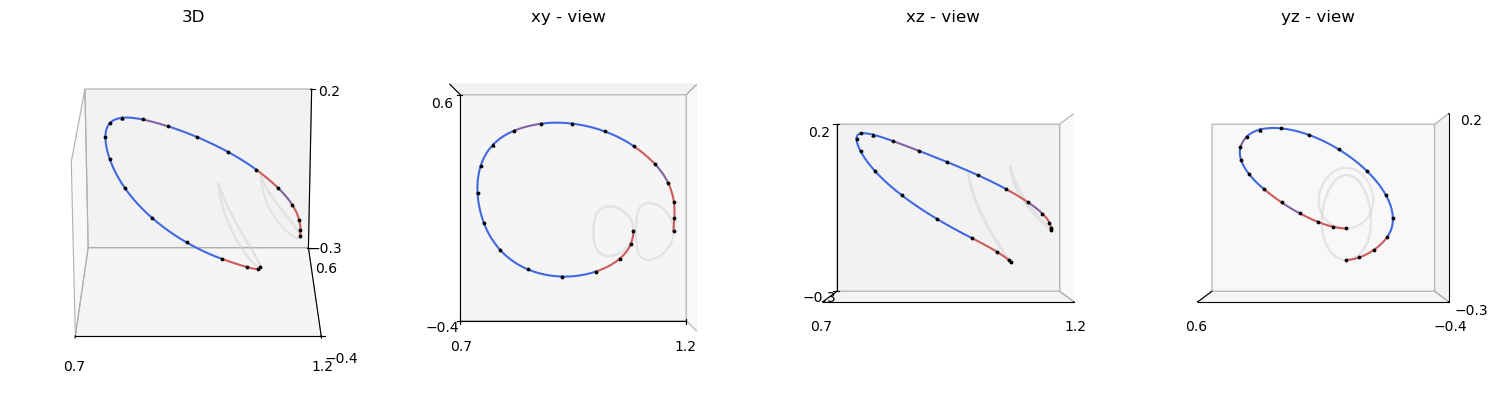

In [23]:
fig = plt.figure(figsize=(15, 4), layout="constrained")

ax3d = fig.add_subplot(1, 4, 1, projection="3d")  # 3D view
ax_xy = fig.add_subplot(1, 4, 2, projection="3d")  # look along +z (XY plane)
ax_xz = fig.add_subplot(1, 4, 3, projection="3d")  # look along +y (XZ plane)
ax_yz = fig.add_subplot(1, 4, 4, projection="3d")  # look along +x (YZ plane)

axes = [ax3d, ax_xy, ax_xz, ax_yz]
#xmin, xmax = 0.8, 1.3
#ymin, ymax = -0.3, 0.3
#zmin, zmax = -0.2, 0.2

for ax in axes:
    udp.plot(
        x=pop.champion_x,
        N=1000,
        mark_segments=True,
        s=3,
        c="k",
        ax=ax,
        orbit_color="lightgray",
    )

# We remove the ticks for clarity
for ax in axes:
    ax.set_xticks([ax.get_xticks()[0], ax.get_xticks()[-1]])
    ax.set_yticks([ax.get_yticks()[0], ax.get_yticks()[-1]])
    ax.set_zticks([ax.get_zticks()[0], ax.get_zticks()[-1]])
ax_xy.set_zticks([])
ax_xz.set_yticks([])
ax_yz.set_xticks([])


ax3d.view_init(elev=20, azim=270)

ax_xy.view_init(elev=90, azim=-90)
ax_xz.view_init(elev=0, azim=-90)
ax_yz.view_init(elev=0, azim=180)

ax3d.set_title("3D")
ax_xy.set_title("xy - view")
ax_xz.set_title("xz - view")
ax_yz.set_title("yz - view")

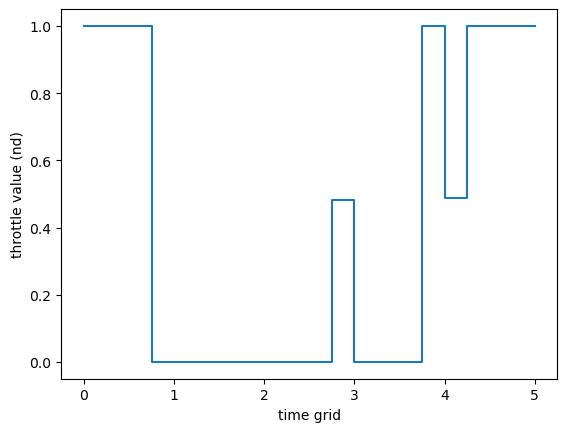

In [24]:
udp.plot_throttle(pop.champion_x);


# Solar-sail dynamics

Finally, we solve a TOPS solar-sail benchmark with {class}`pykep.trajopt.gym.tops_ss`, internally based on {class}`pykep.trajopt.zoh_ss_point2point`.

As above, we keep the same verification-and-solve protocol (gradient check, IPOPT solve, trajectory inspection), so results are directly comparable across dynamics.

For additional sail-leg details, see the [Zero-Order Hold leg tutorial](./leg_zoh.ipynb) and [Trajectory optimization API](../trajopt.rst).

In [3]:
# 1) Load a TOPS solar-sail benchmark
prob_name = "P1"
udp = pk.trajopt.gym.tops_ss(prob_name, nseg=10, time_encoding="uniform")
print(udp.extra_info)

# 2) Build pygmo wrapper
prob = pg.problem(udp)
prob.c_tol = 1e-7 # This affects pagmo feasibility checks, not IPOPT's internal tol

Eccentric (e=0.5, a=2) to highly-eccentric (e=0.9, a=10) orbit at periapsis (rp=1, nd)


In [4]:
# Gradient consistency check for the solar-sail benchmark
pop = pg.population(prob, 1)
grad_err = pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8) - udp.gradient(pop.champion_x)
grad_err.max(), grad_err.min()

(3.4819795660147312e-05, -4.7895323959787003e-06)

In [5]:
# Solve and summarize (for zoh_ss_point2point, tof is the last decision variable)
pop = algo.evolve(pop)
print(prob.feasibility_f(pop.champion_f))
print("Objective:", pop.champion_f[0])
print("Final tof:", pop.champion_x[-1] * udp.TIME)

True
Objective: 180.0
Final tof: 180.0


Text(0.5, 0.92, '3D')

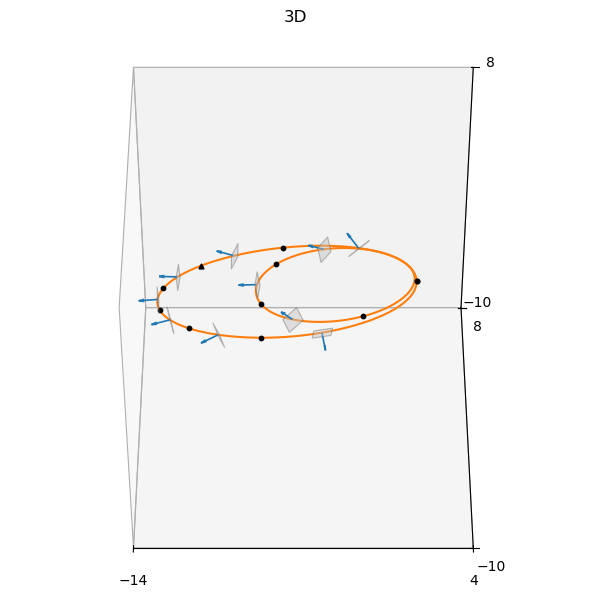

In [6]:
# Single 3D view for the solar-sail trajectory
fig = plt.figure(figsize=(6, 6), layout="constrained")

ax = fig.add_subplot(1, 1, 1, projection="3d")

udp.plot(x=pop.champion_x, N=100, mark_segments=True, ax=ax, sail_size=0.5, s=10, c='k')

ax.set_xticks([ax.get_xticks()[0], ax.get_xticks()[-1]])
ax.set_yticks([ax.get_yticks()[0], ax.get_yticks()[-1]])
ax.set_zticks([ax.get_zticks()[0], ax.get_zticks()[-1]])

ax.view_init(elev=45, azim=270)
ax.set_title("3D")